<div style="display: flex; align-items: center; width: 100%;">  
  <div style="display: flex; flex-direction: column; align-items: center; justify-content: center; width: 100px; margin-right: 0px;">    
    <a href="https://risklab.ai" style="border: 0; line-height: 0.5;">
      <img src="../../Utils/risklab_ai.gif" width="60px" style="border: 0; margin-bottom:-10px; vertical-align: middle;"/>
    </a>
  </div>  
  <div style="flex-grow: 1;">
    <h1 style="margin: 0; margin-left:0; font-weight: bold; text-align: left; font-size: 38px;">
      Fractional Differentiation
    </h1>
  </div>  
</div>

Most ML models assume **stationary** features, but price levels are strongly
non-stationary. The usual fix — taking returns (integer differencing, `d = 1`) —
makes the series stationary but **erases its memory** (returns are nearly
serially uncorrelated). Fractional differentiation takes a *real-valued* order
`0 < d < 1`, achieving stationarity while **keeping as much memory as possible**.

We find the **minimum `d`** that makes a real economic series (the S&P 500 from
FRED) stationary, and show it stays highly correlated with the original level.

Reference: López de Prado, *Advances in Financial Machine Learning*, Ch. 5.

## 1. A real, non-stationary series (FRED)

We pull the S&P 500 index level (`SP500`) from the Federal Reserve's **FRED**
database via `FredData.jl`. It reads your free API key from the `FRED_API_KEY`
environment variable automatically.

In [1]:
using Pkg
Pkg.activate(joinpath(@__DIR__, "..", ".."))   # the pinned notebook environment

using RiskLabAI
using RiskLabAI.Data: find_optimal_ffd, fractional_difference_fixed,
    fractionally_differentiated_log_price
using FredData, DataFrames, Statistics, Plots
gr()
theme(:dark)                                      # dark figures (RiskLabAI house style)
default(background_color = :black, background_color_inside = :black)

  Activating project at `C:\arian\risklabai\Notebooks.jl`


API key loaded.

2609 observations, 2016-06-20 to 2026-06-18


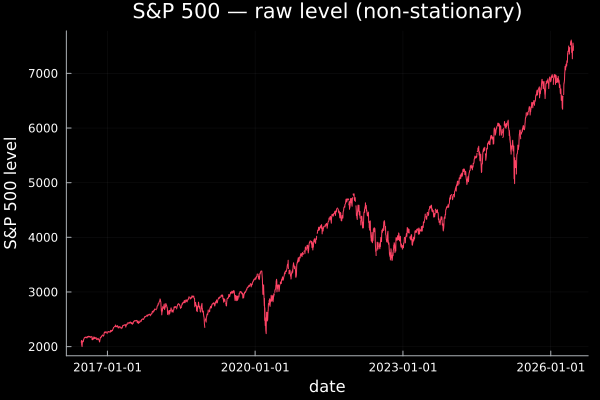

In [2]:
fred = Fred()                       # reads FRED_API_KEY from the environment
series = get_data(fred, "SP500")
df = dropmissing(series.data, :value)
prices = Float64.(df.value)
dates = df.date

println("$(length(prices)) observations, $(dates[1]) to $(dates[end])")
plot(dates, prices; legend = false, lw = 1, xlabel = "date",
     ylabel = "S&P 500 level", title = "S&P 500 — raw level (non-stationary)")

## 2. Sweep the differencing order `d`

`find_optimal_ffd` fixed-width-differentiates the **log** price for `d` from 0 to
1, runs the **Augmented Dickey–Fuller** unit-root test on each, and reports the
ADF statistic, its p-value, and the correlation with the original log-price
(a proxy for retained memory).

In [3]:
sweep = find_optimal_ffd(prices)

DataFrame(d = round.(sweep.d; digits = 2),
          adf_stat = round.(sweep.adf_stat; digits = 3),
          p_value = round.(sweep.p_value; digits = 4),
          correlation = round.(sweep.correlation; digits = 3))

Row,d,adf_stat,p_value,correlation
,Float64,Float64,Float64,Float64
1,0.0,-0.365,0.9158,1.0
2,0.1,-0.504,0.8913,1.0
3,0.2,-0.723,0.8408,0.999
4,0.3,-1.226,0.6623,0.998
5,0.4,-1.774,0.3932,0.994
6,0.5,-2.675,0.0784,0.987
7,0.6,-3.978,0.0015,0.971
8,0.7,-5.629,0.0,0.949
9,0.8,-8.829,0.0,0.882


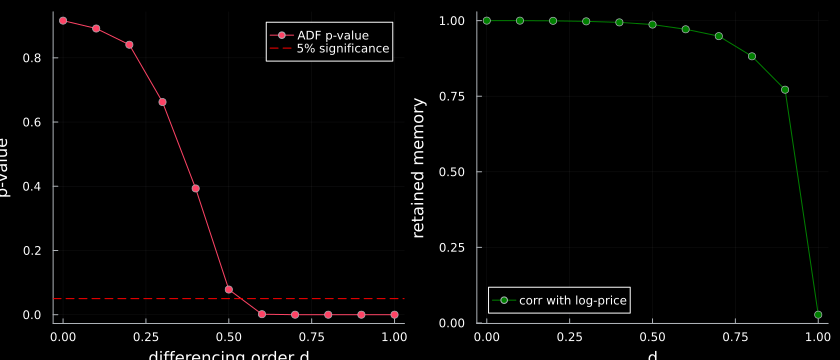

In [4]:
p1 = plot(sweep.d, sweep.p_value; marker = :circle, label = "ADF p-value",
          xlabel = "differencing order d", ylabel = "p-value")
hline!(p1, [0.05]; ls = :dash, c = :red, label = "5% significance")

p2 = plot(sweep.d, sweep.correlation; marker = :circle, c = :green,
          label = "corr with log-price", xlabel = "d", ylabel = "retained memory")

plot(p1, p2; layout = (1, 2), size = (840, 360))

## 3. The minimum `d` for stationarity

The smallest `d` whose ADF p-value drops below 5% is the sweet spot: stationary,
yet still strongly correlated with the original level.

In [5]:
idx = findfirst(<=(0.05), sweep.p_value)
if idx === nothing
    println("No d in [0, 1] achieved stationarity at the 5% level.")
else
    println("minimum d for stationarity: ", sweep.d[idx],
            "   |   ADF p-value = ", round(sweep.p_value[idx]; digits = 4),
            "   |   memory (corr) = ", round(sweep.correlation[idx]; digits = 3))
end

minimum d for stationarity: 0.6   |   ADF p-value = 0.0015   |   memory (corr) = 0.971


## 4. The fractionally differentiated series

`fractionally_differentiated_log_price` increases `d` until the series is
stationary, then returns it. Compared to plain returns (`d = 1`, memoryless),
this series is stationary **and** retains the long-run structure of the market.

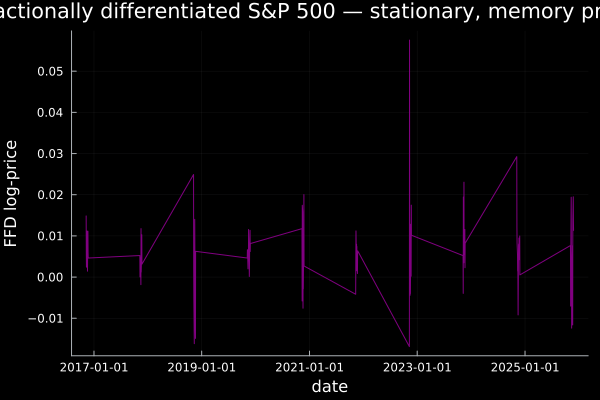

In [6]:
ffd = fractionally_differentiated_log_price(prices)
valid = .!isnan.(ffd)

plot(dates[valid], ffd[valid]; legend = false, lw = 1, c = :purple, xlabel = "date",
     ylabel = "FFD log-price",
     title = "Fractionally differentiated S&P 500 — stationary, memory preserved")

## Takeaways

- Price **levels** carry memory but are non-stationary; **returns** (`d = 1`) are
  stationary but throw the memory away.
- **Fractional differentiation** finds the minimum real `d` that achieves
  stationarity (ADF p-value < 5%) while keeping the highest correlation with the
  original level.
- This gives ML models features that are both stationary *and* informative.

`find_optimal_ffd`, `fractional_difference_fixed`, and
`fractionally_differentiated_log_price` come from `RiskLabAI.Data`.